# spike_discrim analysis workbook

This notebook is the main end-to-end analysis surface for the repository.

It is designed to:
- load waveform data from the repo,
- extract package features from `src/spike_discrim`,
- score single metrics,
- score metric combinations,
- score the new flattened overlapping-window MAD/WTA afferent across configurable time steps,
- plot summary figures,
- generate a confusion matrix for the best candidate,
- save clean tables for later use in the frontend or reports.

Recommendation: keep the repo overview notebook for orientation, but use this notebook for benchmarking, figures, and publishable scoreboards.

In [1]:
from pathlib import Path

import sys

import json

from datetime import datetime, timezone

from fnmatch import fnmatch

from itertools import combinations



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display, Markdown



PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / 'pyproject.toml').exists():

    for parent in [PROJECT_ROOT.parent, PROJECT_ROOT.parent.parent]:

        if (parent / 'pyproject.toml').exists():

            PROJECT_ROOT = parent

            break



SRC_DIR = PROJECT_ROOT / 'src'

if str(SRC_DIR) not in sys.path:

    sys.path.insert(0, str(SRC_DIR))



pd.set_option('display.max_columns', 200)

pd.set_option('display.max_rows', 200)

pd.set_option('display.width', 220)

plt.style.use('ggplot')



from spike_discrim.config.loader import load_benchmark_config, load_config

from spike_discrim.features import (

    SCALAR_FEATURE_NAMES,

    TEMPORAL_MAD_FEATURE_PREFIX,

    build_feature_matrix,

)

from spike_discrim.input_layer.weights import WeightBank

from spike_discrim.io.storage import load_waveforms

from spike_discrim.metrics.evaluation import (

    compute_auc,

    compute_balanced_accuracy,

    compute_confusion_matrix,

    compute_silhouette,

    evaluate_single_feature,

)

from spike_discrim.models.discriminants import make_model



print(f'Project root: {PROJECT_ROOT}')


Project root: /Users/marco/Cursor_Folder/Cursor_Codespace/spike_discrim


## Analysis controls

These settings control what data is loaded, what features are extracted, and how broad the scoring sweep will be.

For a fast iteration loop, reduce `TEMPORAL_BIN_GRID`, `CV_MODELS`, or `MAX_COMBO_SIZE`.

In [9]:
DATA_CANDIDATES = [
    PROJECT_ROOT / 'data' / 'real_units' / 'waveforms_real.npz',
    PROJECT_ROOT / 'data' / 'synthetic' / 'waveforms_real.npz',
    PROJECT_ROOT / 'data' / 'synthetic' / 'waveforms.npz',
]

WAVEFORM_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)

if WAVEFORM_PATH is None:
    raise FileNotFoundError('No waveform NPZ found in data/real_units or data/synthetic/')

DEFAULT_CONFIG = load_config(PROJECT_ROOT / 'configs' / 'default.yaml')
DEFAULT_TEMPORAL_CFG = DEFAULT_CONFIG.get('temporal_mad', {}) or {}

FEATURE_TIER = 3
WINDOW_SIZE_SAMPLES = int(DEFAULT_CONFIG.get('window_size_samples', 16))

BASELINE_TEMPORAL_ENABLED = bool(DEFAULT_TEMPORAL_CFG.get('enabled', False))
BASELINE_TEMPORAL_BINS = int(DEFAULT_TEMPORAL_CFG.get('n_time_bins', 8)) if BASELINE_TEMPORAL_ENABLED else None

TEMPORAL_BIN_GRID = [3, 5, 8, 12, 16]
TEMPORAL_OVERLAP = float(DEFAULT_TEMPORAL_CFG.get('overlap_fraction', 0.50))
TEMPORAL_NOISE_MODE = str(DEFAULT_TEMPORAL_CFG.get('noise_mad_mode', 'none'))
GLOBAL_NOISE_MAD = DEFAULT_TEMPORAL_CFG.get('global_noise_mad')
EDGE_SAMPLES = int(DEFAULT_TEMPORAL_CFG.get('edge_samples', 8))
MAD_SCALE_FACTOR = float(DEFAULT_TEMPORAL_CFG.get('mad_scale_factor', 1.4826))

CV_MODELS = ['lda', 'logistic_regression', 'linear_svm', 'knn_k5']
MAX_COMBO_SIZE = 3
COMBO_FEATURE_POOL = list(SCALAR_FEATURE_NAMES)
RANDOM_SEED = 42
N_CV_FOLDS = 5
TEST_SIZE = 0.25

BENCHMARK_CONFIG = load_benchmark_config(PROJECT_ROOT / 'configs' / 'benchmarks.yaml')

FEATURE_ALIASES = {
    'max_curvature': 'max_abs_curvature',
    'trough_to_peak_time_samples': 'ev_trough_to_peak_time_samples',
    'half_width_samples': 'ev_half_width_samples',
    'full_width_samples': 'ev_full_width_samples',
    'biphasic_ratio': 'ev_biphasic_ratio',
    'baseline_rms': 'ev_baseline_rms',
    'signed_area': 'ev_signed_area',
    'absolute_area': 'ev_absolute_area',
    'zero_crossing_count': 'ev_zero_crossing_count',
}

config_preview = pd.DataFrame([
    {'setting': 'waveform_path', 'value': str(WAVEFORM_PATH.relative_to(PROJECT_ROOT))},
    {'setting': 'feature_tier', 'value': FEATURE_TIER},
    {'setting': 'window_size_samples', 'value': WINDOW_SIZE_SAMPLES},
    {'setting': 'baseline_temporal_enabled', 'value': BASELINE_TEMPORAL_ENABLED},
    {'setting': 'baseline_temporal_bins', 'value': BASELINE_TEMPORAL_BINS},
    {'setting': 'temporal_bin_grid', 'value': TEMPORAL_BIN_GRID},
    {'setting': 'temporal_overlap', 'value': TEMPORAL_OVERLAP},
    {'setting': 'temporal_noise_mode', 'value': TEMPORAL_NOISE_MODE},
    {'setting': 'cv_models', 'value': CV_MODELS},
    {'setting': 'max_combo_size', 'value': MAX_COMBO_SIZE},
])

display(config_preview)

,setting,value
0,waveform_path,data/synthetic/waveforms_real.npz
1,feature_tier,3
2,window_size_samples,16
3,temporal_bin_grid,"[3, 5, 8, 12, 16]"
4,temporal_overlap,0.5
5,temporal_noise_mode,none
6,cv_models,"[lda, logistic_regression, knn_k5]"
7,max_combo_size,3
8,max_combos_per_size,12


In [3]:
loaded = load_waveforms(WAVEFORM_PATH)
waveforms = loaded['waveforms'].astype(np.float32)
class_labels = loaded.get('class_labels', np.ones(len(waveforms), dtype=np.int32)).astype(np.int32)
unit_ids = loaded.get('unit_ids', np.zeros(len(waveforms), dtype=np.int32)).astype(np.int32)

N_SNIPPETS, N_SAMPLES = waveforms.shape
unique_classes = np.unique(class_labels)

summary_df = pd.DataFrame([
    {'field': 'n_snippets', 'value': int(N_SNIPPETS)},
    {'field': 'n_samples_per_snippet', 'value': int(N_SAMPLES)},
    {'field': 'n_spikes', 'value': int((class_labels == 1).sum())},
    {'field': 'n_noise', 'value': int((class_labels == 0).sum())},
    {'field': 'n_unique_units', 'value': int(len(np.unique(unit_ids[class_labels == 1])))},
    {'field': 'class_values', 'value': unique_classes.tolist()},
])
display(summary_df)

if len(unique_classes) < 2:
    display(Markdown('**Warning:** only one class label is present. Binary discrimination metrics will be limited.'))

unit_counts = pd.Series(unit_ids[class_labels == 1]).value_counts().sort_index()
display(unit_counts.rename_axis('unit_id').reset_index(name='n_spikes_per_unit').head(20))

,field,value
0,n_snippets,96006
1,n_samples_per_snippet,64
2,n_spikes,38145
3,n_noise,57861
4,n_unique_units,10
5,class_values,"[0, 1]"


,unit_id,n_spikes_per_unit
0,1,982
1,2,2557
2,3,3493
3,4,707
4,5,5914
5,6,3539
6,7,2175
7,8,15057
8,9,742
9,10,2979


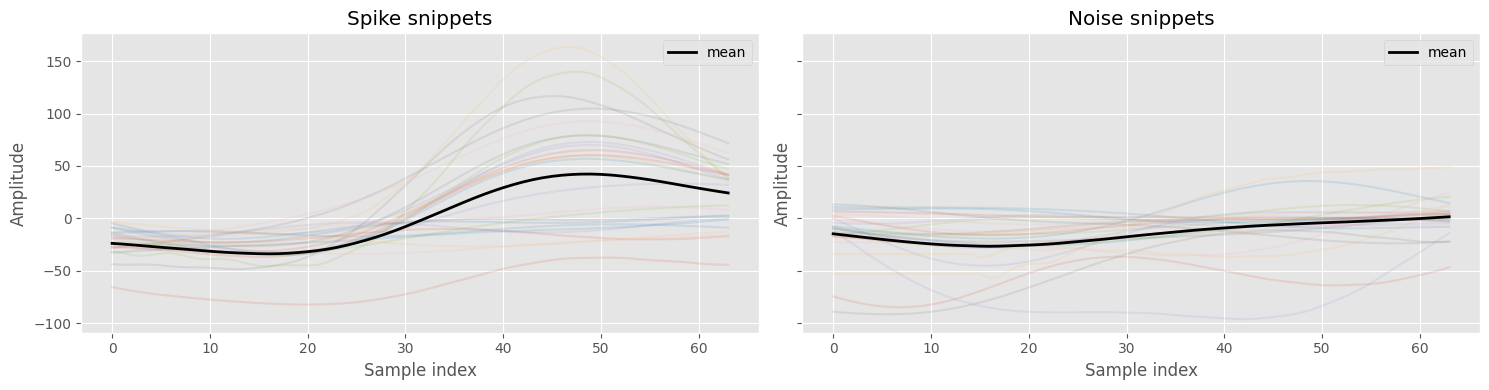

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
plot_specs = [
    (1, 'Spike snippets'),
    (0, 'Noise snippets'),
]

for ax, (label_value, title) in zip(axes, plot_specs):
    idx = np.where(class_labels == label_value)[0]
    ax.set_title(title)
    ax.set_xlabel('Sample index')
    ax.set_ylabel('Amplitude')
    if len(idx) == 0:
        ax.text(0.5, 0.5, 'No examples available', ha='center', va='center', transform=ax.transAxes)
        continue
    chosen = rng.choice(idx, size=min(25, len(idx)), replace=False)
    ax.plot(waveforms[chosen].T, alpha=0.15)
    ax.plot(waveforms[idx].mean(axis=0), color='black', linewidth=2.0, label='mean')
    ax.legend()

plt.tight_layout()
plt.show()

## Feature extraction helpers

This section keeps the notebook clean by calling package functions from `src/spike_discrim` rather than re-implementing kernels inline.

In [5]:
def extract_feature_dataframe(

    waveforms,

    class_labels,

    unit_ids,

    tier=3,

    window_size_samples=16,

    temporal_bins=None,

    temporal_overlap=0.5,

    temporal_noise_mode='none',

    global_noise_mad=None,

    edge_samples=8,

    mad_scale_factor=1.4826,

):

    cfg = {

        'window_size_samples': int(window_size_samples),

        'temporal_mad': {

            'enabled': temporal_bins is not None,

            'n_time_bins': None if temporal_bins is None else int(temporal_bins),

            'overlap_fraction': float(temporal_overlap),

            'noise_mad_mode': str(temporal_noise_mode),

            'global_noise_mad': global_noise_mad,

            'edge_samples': int(edge_samples),

            'mad_scale_factor': float(mad_scale_factor),

        },

    }



    feature_matrix, feature_names, metadata = build_feature_matrix(

        waveforms=np.ascontiguousarray(waveforms, dtype=np.float32),

        cfg=cfg,

        tier=int(tier),

    )



    feature_df = pd.DataFrame(feature_matrix, columns=feature_names)

    feature_df['class_label'] = np.asarray(class_labels, dtype=np.int32)

    feature_df['unit_id'] = np.asarray(unit_ids, dtype=np.int32)

    return feature_df, metadata





baseline_features_df, baseline_metadata = extract_feature_dataframe(

    waveforms=waveforms,

    class_labels=class_labels,

    unit_ids=unit_ids,

    tier=FEATURE_TIER,

    window_size_samples=WINDOW_SIZE_SAMPLES,

    temporal_bins=BASELINE_TEMPORAL_BINS,

    temporal_overlap=TEMPORAL_OVERLAP,

    temporal_noise_mode=TEMPORAL_NOISE_MODE,

    global_noise_mad=GLOBAL_NOISE_MAD,

    edge_samples=EDGE_SAMPLES,

    mad_scale_factor=MAD_SCALE_FACTOR,

)



BASE_FEATURE_COLUMNS = [

    c for c in baseline_features_df.columns

    if c not in {'class_label', 'unit_id'}

]



display(pd.DataFrame([

    {'field': 'baseline_feature_count', 'value': len(BASE_FEATURE_COLUMNS)},

    {'field': 'scalar_features', 'value': len(SCALAR_FEATURE_NAMES)},

    {'field': 'baseline_temporal_bins', 'value': BASELINE_TEMPORAL_BINS},

    {'field': 'temporal_mad_enabled', 'value': bool(baseline_metadata.get('temporal_mad'))},

    {'field': 'event_features_included', 'value': FEATURE_TIER >= 3},

]))

display(pd.DataFrame({'feature_name': BASE_FEATURE_COLUMNS}).head(30))


,field,value
0,baseline_feature_count,18
1,scalar_features,6
2,event_features_included,True


,feature_name
0,peak_amplitude
1,trough_amplitude
2,max_slope
3,min_slope
4,max_abs_curvature
5,abs_window_sum_peak
6,ev_trough_amplitude
7,ev_peak_amplitude
8,ev_trough_to_peak_time_samples
9,ev_half_width_samples


## Scoring helpers

The next cell builds the table engine used for:
- single-feature ranking,
- configured benchmark sets,
- exhaustive scalar combinations up to a chosen size,
- temporal MAD-only sweeps,
- baseline plus temporal MAD sweeps.

In [10]:
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
import warnings


def expand_feature_specs(feature_specs, available_feature_names):
    expanded = []
    seen = set()
    for spec in feature_specs:
        mapped = FEATURE_ALIASES.get(spec, spec)
        matches = [name for name in available_feature_names if fnmatch(name, mapped)]
        if not matches and mapped in available_feature_names:
            matches = [mapped]
        for match in matches:
            if match not in seen:
                expanded.append(match)
                seen.add(match)
    return expanded


def make_notebook_model(model_name):
    if model_name == 'lda':
        return make_pipeline(StandardScaler(), LinearDiscriminantAnalysis())
    if model_name == 'logistic_regression':
        return make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=3000, solver='lbfgs', random_state=RANDOM_SEED),
        )
    if model_name == 'linear_svm':
        return make_pipeline(
            StandardScaler(),
            LinearSVC(max_iter=5000, C=1.0, random_state=RANDOM_SEED),
        )
    if model_name == 'knn_k5':
        return make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
    if model_name == 'nearest_centroid':
        return make_model(model_name)
    raise ValueError(f'Unsupported notebook model: {model_name}')


def cross_validated_weight_bank(X, y, feature_names, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    aucs = []
    bal_accs = []
    for train_idx, test_idx in skf.split(X, y):
        X_train = X[train_idx].astype(np.float32)
        y_train = y[train_idx].astype(np.int32)
        X_test = X[test_idx].astype(np.float32)
        y_test = y[test_idx].astype(np.int32)

        spike_mask = y_train == 1
        if spike_mask.sum() == 0:
            continue

        wb = WeightBank(n_bins=10, sigma_scale=1.0, threshold=0.5)
        wb.fit(X_train[spike_mask], feature_names=list(feature_names))
        wb.warmup()
        scores = wb.score_batch(X_test)
        preds = wb.classify(X_test).astype(np.int32)
        aucs.append(compute_auc(y_test, scores))
        bal_accs.append(compute_balanced_accuracy(y_test, preds))

    return {
        'weight_bank_auc_mean': float(np.mean(aucs)) if aucs else np.nan,
        'weight_bank_auc_std': float(np.std(aucs)) if aucs else np.nan,
        'weight_bank_bal_acc_mean': float(np.mean(bal_accs)) if bal_accs else np.nan,
        'weight_bank_bal_acc_std': float(np.std(bal_accs)) if bal_accs else np.nan,
    }


def score_feature_set(
    feature_df,
    feature_cols,
    labels,
    unit_ids,
    set_name,
    category,
    scenario_key,
    n_time_bins=np.nan,
    cv_models=None,
    n_cv_folds=5,
    seed=42,
    include_weight_bank=True,
    verbose=False,
    ):
    if cv_models is None:
        cv_models = ['lda', 'logistic_regression', 'knn_k5']

    feature_cols = list(feature_cols)
    X = feature_df.loc[:, feature_cols].to_numpy(dtype=np.float32)
    y = labels.astype(np.int32)

    sil_binary = compute_silhouette(X, y)
    spike_mask = y == 1
    sil_units = np.nan
    if spike_mask.sum() > 3 and len(np.unique(unit_ids[spike_mask])) > 1:
        sil_units = compute_silhouette(X[spike_mask], unit_ids[spike_mask])

    rows = []
    skf = StratifiedKFold(n_splits=n_cv_folds, shuffle=True, random_state=seed)

    for model_name in cv_models:
        try:
            model = make_notebook_model(model_name)
            with warnings.catch_warnings():
                warnings.filterwarnings('ignore', category=ConvergenceWarning)
                cv_res = cross_validate(
                    model,
                    X,
                    y,
                    cv=skf,
                    scoring={'balanced_acc': 'balanced_accuracy', 'roc_auc': 'roc_auc'},
                    return_train_score=False,
                    error_score='raise',
                )
            rows.append({
                'set_name': set_name,
                'category': category,
                'scenario_key': scenario_key,
                'n_time_bins': n_time_bins,
                'model': model_name,
                'n_features': len(feature_cols),
                'feature_columns': feature_cols,
                'balanced_acc_mean': float(np.mean(cv_res['test_balanced_acc'])),
                'balanced_acc_std': float(np.std(cv_res['test_balanced_acc'])),
                'auc_mean': float(np.mean(cv_res['test_roc_auc'])),
                'auc_std': float(np.std(cv_res['test_roc_auc'])),
                'silhouette_binary': sil_binary,
                'silhouette_units': sil_units,
            })
        except Exception as exc:
            rows.append({
                'set_name': set_name,
                'category': category,
                'scenario_key': scenario_key,
                'n_time_bins': n_time_bins,
                'model': model_name,
                'n_features': len(feature_cols),
                'feature_columns': feature_cols,
                'balanced_acc_mean': np.nan,
                'balanced_acc_std': np.nan,
                'auc_mean': np.nan,
                'auc_std': np.nan,
                'silhouette_binary': sil_binary,
                'silhouette_units': sil_units,
                'error': str(exc),
            })

    if include_weight_bank:
        wb_stats = cross_validated_weight_bank(
            X=X,
            y=y,
            feature_names=feature_cols,
            n_splits=n_cv_folds,
            seed=seed,
        )
        rows.append({
            'set_name': set_name,
            'category': category,
            'scenario_key': scenario_key,
            'n_time_bins': n_time_bins,
            'model': 'weight_bank',
            'n_features': len(feature_cols),
            'feature_columns': feature_cols,
            'balanced_acc_mean': wb_stats['weight_bank_bal_acc_mean'],
            'balanced_acc_std': wb_stats['weight_bank_bal_acc_std'],
            'auc_mean': wb_stats['weight_bank_auc_mean'],
            'auc_std': wb_stats['weight_bank_auc_std'],
            'silhouette_binary': sil_binary,
            'silhouette_units': sil_units,
        })

    if verbose:
        print(f'Finished: {set_name} ({category}) with {len(feature_cols)} features')

    return rows


def build_scalar_combo_specs(feature_pool, max_size=3, max_combos_per_size=None, seed=42):
    rng = np.random.default_rng(seed)
    specs = []
    for r in range(1, max_size + 1):
        combos = list(combinations(feature_pool, r))
        if max_combos_per_size is not None and len(combos) > max_combos_per_size:
            chosen_idx = np.sort(rng.choice(len(combos), size=max_combos_per_size, replace=False))
            combos = [combos[i] for i in chosen_idx]
        for combo in combos:
            specs.append({
                'name': ' + '.join(combo),
                'category': f'scalar_combo_r{r}',
                'feature_columns': list(combo),
            })
    return specs

In [11]:
single_feature_rows = []
for feature_name in BASE_FEATURE_COLUMNS:
    row = evaluate_single_feature(
        feature_col=baseline_features_df[feature_name].to_numpy(dtype=np.float32),
        labels=class_labels,
        feature_name=feature_name,
        model_names=CV_MODELS,
    )
    single_feature_rows.append(row)

single_feature_df = pd.DataFrame(single_feature_rows)
sort_cols = [c for c in ['fisher_score', 'auc'] if c in single_feature_df.columns]
single_feature_df = single_feature_df.sort_values(sort_cols, ascending=[False] * len(sort_cols)).reset_index(drop=True)
single_feature_df['rank'] = np.arange(1, len(single_feature_df) + 1)

single_feature_view_cols = [
    c for c in [
        'rank',
        'feature',
        'fisher_score',
        'mutual_info',
        'auc',
        'lda_balanced_acc_mean',
        'logistic_regression_balanced_acc_mean',
        'linear_svm_balanced_acc_mean',
        'knn_k5_balanced_acc_mean',
    ]
    if c in single_feature_df.columns
]

display(Markdown('## Single-feature ranking'))
display(single_feature_df[single_feature_view_cols].head(25))

## Single-feature ranking

,rank,feature,fisher_score,mutual_info,auc,lda_balanced_acc_mean,logistic_regression_balanced_acc_mean,knn_k5_balanced_acc_mean
0,1,peak_amplitude,0.490437,0.178314,0.694484,0.745582,0.741584,0.776509
1,2,ev_peak_amplitude,0.490437,0.178314,0.694484,0.745582,0.741584,0.776509
2,3,ev_absolute_area,0.309140,0.051189,0.796028,0.645570,0.705763,0.702330
3,4,max_slope,0.289578,0.078336,0.723335,0.678943,0.711318,0.678773
4,5,ev_max_rising_slope,0.289578,0.078336,0.723335,0.678943,0.711318,0.678773
5,6,abs_window_sum_peak,0.285015,0.056765,0.770773,0.642271,0.679239,0.669712
6,7,ev_signed_area,0.244005,0.119750,0.693562,0.730000,0.737074,0.736241
7,8,ev_full_width_samples,0.056858,0.147748,0.631295,0.492643,0.492643,0.699783
8,9,ev_zero_crossing_count,0.056834,0.025099,0.566910,0.515746,0.515746,0.514183
9,10,min_slope,0.041221,0.014944,0.625086,0.524480,0.538224,0.558178


In [12]:
feature_frames = {'baseline': baseline_features_df}
scoreboard_rows = []

configured_sets = BENCHMARK_CONFIG.get('feature_sets', [])
display(Markdown(f'## Running scoreboard sweep\nConfigured sets: **{len(configured_sets)}**  \nModels per set: **{len(CV_MODELS) + 1}** including WeightBank'))

# Configured benchmark sets that resolve against the current extracted columns
for idx, fset in enumerate(configured_sets, start=1):
    cols = expand_feature_specs(fset.get('scalar_features', []), BASE_FEATURE_COLUMNS)
    if not cols:
        continue
    print(f'Configured set {idx}/{len(configured_sets)}: {fset["name"]} ({len(cols)} features)')
    scoreboard_rows.extend(
        score_feature_set(
            feature_df=baseline_features_df,
            feature_cols=cols,
            labels=class_labels,
            unit_ids=unit_ids,
            set_name=fset['name'],
            category='configured',
            scenario_key='baseline',
            n_time_bins=np.nan,
            cv_models=CV_MODELS,
            n_cv_folds=N_CV_FOLDS,
            seed=RANDOM_SEED,
        )
    )

# Exhaustive scalar combinations up to MAX_COMBO_SIZE, optionally sampled for notebook speed
combo_specs = build_scalar_combo_specs(
    COMBO_FEATURE_POOL,
    max_size=MAX_COMBO_SIZE,
    max_combos_per_size=MAX_COMBOS_PER_SIZE,
    seed=RANDOM_SEED,
)
print(f'Scalar combo specs: {len(combo_specs)}')
for idx, spec in enumerate(combo_specs, start=1):
    if idx % 10 == 1 or idx == len(combo_specs):
        print(f'Combo {idx}/{len(combo_specs)}: {spec["name"]}')
    scoreboard_rows.extend(
        score_feature_set(
            feature_df=baseline_features_df,
            feature_cols=spec['feature_columns'],
            labels=class_labels,
            unit_ids=unit_ids,
            set_name=spec['name'],
            category=spec['category'],
            scenario_key='baseline',
            n_time_bins=np.nan,
            cv_models=CV_MODELS,
            n_cv_folds=N_CV_FOLDS,
            seed=RANDOM_SEED,
            include_weight_bank=(len(spec['feature_columns']) > 1),
        )
    )

# Temporal MAD sweeps
temporal_summaries = []
for n_bins in TEMPORAL_BIN_GRID:
    print(f'Temporal sweep: {n_bins} bins')
    temporal_df, temporal_meta = extract_feature_dataframe(
        waveforms=waveforms,
        class_labels=class_labels,
        unit_ids=unit_ids,
        tier=FEATURE_TIER,
        window_size_samples=WINDOW_SIZE_SAMPLES,
        temporal_bins=n_bins,
        temporal_overlap=TEMPORAL_OVERLAP,
        temporal_noise_mode=TEMPORAL_NOISE_MODE,
        global_noise_mad=GLOBAL_NOISE_MAD,
        edge_samples=EDGE_SAMPLES,
        mad_scale_factor=MAD_SCALE_FACTOR,
    )
    scenario_key = f'temporal_{n_bins}'
    feature_frames[scenario_key] = temporal_df

    temporal_cols = [
        c for c in temporal_df.columns
        if c.startswith(TEMPORAL_MAD_FEATURE_PREFIX)
    ]

    temporal_summaries.append({
        'n_time_bins': int(n_bins),
        'temporal_feature_count': len(temporal_cols),
        'window_starts': temporal_meta['temporal_mad']['window_starts'],
        'window_ends': temporal_meta['temporal_mad']['window_ends'],
    })

    scoreboard_rows.extend(
        score_feature_set(
            feature_df=temporal_df,
            feature_cols=temporal_cols,
            labels=class_labels,
            unit_ids=unit_ids,
            set_name=f'temporal_mad_only_{n_bins}bins',
            category='temporal_only',
            scenario_key=scenario_key,
            n_time_bins=n_bins,
            cv_models=CV_MODELS,
            n_cv_folds=N_CV_FOLDS,
            seed=RANDOM_SEED,
        )
    )

    combined_cols = BASE_FEATURE_COLUMNS + temporal_cols
    scoreboard_rows.extend(
        score_feature_set(
            feature_df=temporal_df,
            feature_cols=combined_cols,
            labels=class_labels,
            unit_ids=unit_ids,
            set_name=f'baseline_plus_temporal_mad_{n_bins}bins',
            category='baseline_plus_temporal',
            scenario_key=scenario_key,
            n_time_bins=n_bins,
            cv_models=CV_MODELS,
            n_cv_folds=N_CV_FOLDS,
            seed=RANDOM_SEED,
        )
    )

scoreboard_df = pd.DataFrame(scoreboard_rows)
scoreboard_df = scoreboard_df.sort_values(
    ['balanced_acc_mean', 'auc_mean', 'silhouette_units'],
    ascending=[False, False, False],
    na_position='last',
).reset_index(drop=True)
scoreboard_df['rank'] = np.arange(1, len(scoreboard_df) + 1)

leaderboard_cols = [
    'rank',
    'set_name',
    'category',
    'model',
    'n_time_bins',
    'n_features',
    'balanced_acc_mean',
    'auc_mean',
    'silhouette_units',
]

display(Markdown('## Overall scoreboard'))
display(scoreboard_df[leaderboard_cols].head(40))

display(Markdown('## Temporal window summaries'))
display(pd.DataFrame(temporal_summaries))

## Running scoreboard sweep
Configured sets: **6**  
Models per set: **4** including WeightBank

Configured set 1/6: set_A_ultra_fast (5 features)
Configured set 2/6: set_B_fast_plus_shape (6 features)
Configured set 4/6: set_C_refined_discrimination (7 features)
Configured set 5/6: set_D_combined (13 features)
Configured set 6/6: set_E_combined_plus_temporal_mad (13 features)
Scalar combo specs: 30
Combo 1/30: peak_amplitude
Combo 11/30: trough_amplitude + max_slope
Combo 21/30: peak_amplitude + max_slope + min_slope
Combo 30/30: max_slope + max_abs_curvature + abs_window_sum_peak
Temporal sweep: 3 bins
Temporal sweep: 5 bins
Temporal sweep: 8 bins
Temporal sweep: 12 bins
Temporal sweep: 16 bins


## Overall scoreboard

,rank,set_name,category,model,n_time_bins,n_features,balanced_acc_mean,auc_mean,silhouette_units
0,1,baseline_plus_temporal_mad_16bins,baseline_plus_temporal,knn_k5,16.0,34,0.901714,0.951466,0.205145
1,2,baseline_plus_temporal_mad_12bins,baseline_plus_temporal,knn_k5,12.0,30,0.901209,0.950590,0.217612
2,3,baseline_plus_temporal_mad_8bins,baseline_plus_temporal,knn_k5,8.0,26,0.898868,0.949762,0.188334
3,4,baseline_plus_temporal_mad_5bins,baseline_plus_temporal,knn_k5,5.0,23,0.896547,0.947825,0.195988
4,5,baseline_plus_temporal_mad_3bins,baseline_plus_temporal,knn_k5,3.0,21,0.895939,0.946958,0.192683
5,6,set_D_combined,configured,knn_k5,NaN,13,0.894425,0.946733,0.212892
6,7,set_E_combined_plus_temporal_mad,configured,knn_k5,NaN,13,0.894425,0.946733,0.179110
7,8,set_C_refined_discrimination,configured,knn_k5,NaN,7,0.879773,0.935701,0.065076
8,9,set_B_fast_plus_shape,configured,knn_k5,NaN,6,0.870176,0.926215,-0.065380
9,10,set_A_ultra_fast,configured,knn_k5,NaN,5,0.869140,0.925299,0.255717


## Temporal window summaries

,n_time_bins,temporal_feature_count,window_starts,window_ends
0,3,3,"[0, 16, 32]","[32, 48, 64]"
1,5,5,"[0, 10, 21, 32, 42]","[22, 32, 43, 54, 64]"
2,8,8,"[0, 7, 14, 21, 28, 35, 42, 49]","[15, 22, 29, 36, 43, 50, 57, 64]"
3,12,12,"[0, 5, 10, 15, 20, 25, 29, 34, 39, 44, 49, 54]","[10, 15, 20, 25, 30, 35, 39, 44, 49, 54, 59, 64]"
4,16,16,"[0, 4, 7, 11, 15, 19, 22, 26, 30, 34, 37, 41, ...","[8, 12, 15, 19, 23, 27, 30, 34, 38, 42, 45, 49..."


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Top single features by Fisher score
top_single = single_feature_df.head(15).sort_values('fisher_score', ascending=True)
axes[0, 0].barh(top_single['feature'], top_single['fisher_score'])
axes[0, 0].set_title('Top single features by Fisher score')
axes[0, 0].set_xlabel('Fisher score')

# Top overall scoreboard rows
top_scoreboard = scoreboard_df.head(20).sort_values('balanced_acc_mean', ascending=True)
labels_for_plot = top_scoreboard['set_name'] + ' | ' + top_scoreboard['model']
axes[0, 1].barh(labels_for_plot, top_scoreboard['balanced_acc_mean'])
axes[0, 1].set_title('Top feature sets by balanced accuracy')
axes[0, 1].set_xlabel('Balanced accuracy')

# Complexity vs performance
for category, cat_df in scoreboard_df.groupby('category'):
    axes[1, 0].scatter(
        cat_df['n_features'],
        cat_df['balanced_acc_mean'],
        alpha=0.7,
        label=category,
    )
axes[1, 0].set_title('Complexity vs performance')
axes[1, 0].set_xlabel('Number of features')
axes[1, 0].set_ylabel('Balanced accuracy')
axes[1, 0].legend(fontsize=8)

# Temporal sweep summary
temporal_plot_df = scoreboard_df[scoreboard_df['category'].isin(['temporal_only', 'baseline_plus_temporal'])].copy()
for model_name in ['weight_bank', 'lda', 'logistic_regression']:
    subset = temporal_plot_df[temporal_plot_df['model'] == model_name]
    if len(subset) == 0:
        continue
    for category in ['temporal_only', 'baseline_plus_temporal']:
        cat_subset = subset[subset['category'] == category].sort_values('n_time_bins')
        if len(cat_subset) == 0:
            continue
        axes[1, 1].plot(
            cat_subset['n_time_bins'],
            cat_subset['balanced_acc_mean'],
            marker='o',
            label=f'{model_name} | {category}',
        )
axes[1, 1].set_title('Temporal bin sweep')
axes[1, 1].set_xlabel('Number of time bins')
axes[1, 1].set_ylabel('Balanced accuracy')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Best candidate summary

,field,value
0,best_set_name,baseline_plus_temporal_mad_16bins
1,best_category,baseline_plus_temporal
2,best_model,knn_k5
3,n_time_bins,16
4,n_features,34
5,cv_balanced_accuracy_mean,0.901714
6,cv_auc_mean,0.951466
7,holdout_balanced_accuracy,0.90375
8,holdout_auc,0.951131


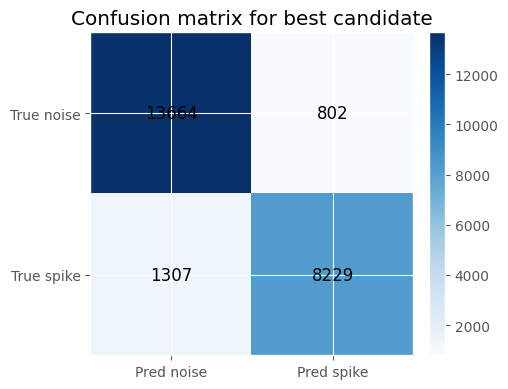

,TP,FP,TN,FN,precision,recall,fpr
0,8229,802,13664,1307,0.911195,0.86294,0.05544


In [13]:
best_row = scoreboard_df.iloc[0].copy()
best_feature_frame = feature_frames[best_row['scenario_key']]
best_feature_columns = list(best_row['feature_columns'])
X_best = best_feature_frame.loc[:, best_feature_columns].to_numpy(dtype=np.float32)
y_best = class_labels.astype(np.int32)

X_train, X_test, y_train, y_test = train_test_split(
    X_best,
    y_best,
    test_size=TEST_SIZE,
    stratify=y_best,
    random_state=RANDOM_SEED,
)

if best_row['model'] == 'weight_bank':
    wb = WeightBank(n_bins=10, sigma_scale=1.0, threshold=0.5)
    wb.fit(X_train[y_train == 1], feature_names=best_feature_columns)
    wb.warmup()
    y_score = wb.score_batch(X_test)
    y_pred = wb.classify(X_test).astype(np.int32)
else:
    best_model = make_notebook_model(best_row['model'])
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=ConvergenceWarning)
        best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test).astype(np.int32)
    if hasattr(best_model, 'predict_proba'):
        y_score = best_model.predict_proba(X_test)[:, 1]
    elif hasattr(best_model, 'decision_function'):
        raw = best_model.decision_function(X_test)
        y_score = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)
    else:
        y_score = y_pred.astype(float)

cm_dict = compute_confusion_matrix(y_test, y_pred)
holdout_bal_acc = compute_balanced_accuracy(y_test, y_pred)
holdout_auc = compute_auc(y_test, y_score)

best_model_summary = pd.DataFrame([
    {'field': 'best_set_name', 'value': best_row['set_name']},
    {'field': 'best_category', 'value': best_row['category']},
    {'field': 'best_model', 'value': best_row['model']},
    {'field': 'n_time_bins', 'value': None if pd.isna(best_row['n_time_bins']) else int(best_row['n_time_bins'])},
    {'field': 'n_features', 'value': int(best_row['n_features'])},
    {'field': 'cv_balanced_accuracy_mean', 'value': float(best_row['balanced_acc_mean'])},
    {'field': 'cv_auc_mean', 'value': float(best_row['auc_mean'])},
    {'field': 'holdout_balanced_accuracy', 'value': float(holdout_bal_acc)},
    {'field': 'holdout_auc', 'value': float(holdout_auc)},
])
display(Markdown('## Best candidate summary'))
display(best_model_summary)

cm_matrix = np.array([
    [cm_dict['TN'], cm_dict['FP']],
    [cm_dict['FN'], cm_dict['TP']],
], dtype=np.int32)

best_cm_fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_matrix, cmap='Blues')
ax.set_title('Confusion matrix for best candidate')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Pred noise', 'Pred spike'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['True noise', 'True spike'])
for i in range(cm_matrix.shape[0]):
    for j in range(cm_matrix.shape[1]):
        ax.text(j, i, int(cm_matrix[i, j]), ha='center', va='center', color='black', fontsize=12)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

display(pd.DataFrame([cm_dict]))

In [ ]:
timestamp = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')
output_dir = PROJECT_ROOT / 'data' / 'results' / 'notebook_analysis' / timestamp
output_dir.mkdir(parents=True, exist_ok=True)

single_feature_df.to_parquet(output_dir / 'single_feature_scores.parquet', index=False)

scoreboard_to_save = scoreboard_df.copy()
scoreboard_to_save['feature_columns'] = scoreboard_to_save['feature_columns'].apply(lambda x: '|'.join(x) if isinstance(x, list) else x)
scoreboard_to_save.to_parquet(output_dir / 'scoreboard.parquet', index=False)
scoreboard_to_save.to_csv(output_dir / 'scoreboard.csv', index=False)

best_model_summary.to_csv(output_dir / 'best_model_summary.csv', index=False)
pd.DataFrame([cm_dict]).to_csv(output_dir / 'best_confusion_matrix_summary.csv', index=False)
best_cm_fig.savefig(output_dir / 'best_confusion_matrix.png', dpi=160, bbox_inches='tight')

analysis_manifest = {
    'waveform_path': str(WAVEFORM_PATH),
    'feature_tier': FEATURE_TIER,
    'window_size_samples': WINDOW_SIZE_SAMPLES,
    'temporal_bin_grid': TEMPORAL_BIN_GRID,
    'temporal_overlap': TEMPORAL_OVERLAP,
    'temporal_noise_mode': TEMPORAL_NOISE_MODE,
    'global_noise_mad': GLOBAL_NOISE_MAD,
    'edge_samples': EDGE_SAMPLES,
    'mad_scale_factor': MAD_SCALE_FACTOR,
    'cv_models': CV_MODELS,
    'max_combo_size': MAX_COMBO_SIZE,
    'n_cv_folds': N_CV_FOLDS,
    'random_seed': RANDOM_SEED,
    'created_at_utc': datetime.now(timezone.utc).isoformat(),
}

with open(output_dir / 'analysis_manifest.json', 'w') as fh:
    json.dump(analysis_manifest, fh, indent=2)

display(Markdown(f'## Saved outputs\nResults written to: **{output_dir.relative_to(PROJECT_ROOT)}**'))

## Notes

- This notebook already uses the repo like a package by importing functions from `src/spike_discrim`.
- That means you can keep notebooks thin and analysis-focused without moving logic into notebook cells.
- This does not touch the frontend and should not break the web view.
- A good next web step is to load the exported scoreboard and confusion-matrix outputs and show:
  - a ranked scoreboard table,
  - the best confusion matrix,
  - the best temporal sweep plot.